# Used Car Price Prediction - Regression Workflow

This notebook presents the complete machine learning workflow for predicting used car prices in USD.

The target variable is `priceUSD`.

This is a regression problem because the model does not predict a class or category. Instead, it predicts a continuous numerical value: the estimated price of a used car.

The workflow follows these steps:

1. Load and inspect the dataset
2. Analyze missing values and outliers
3. Clean the data
4. Create additional features
5. Prepare numerical and categorical columns
6. Train and compare multiple regression models
7. Evaluate the final model using regression metrics
8. Interpret the results in a business context

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_cleaning import clean_cars_data
from src.feature_engineering import engineer_features

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

In [2]:
project_root = Path('..')
raw_path = project_root / 'data' / 'cars.csv'

df_raw = pd.read_csv(raw_path)
print(f'Raw shape: {df_raw.shape}')
df_raw.head()

Raw shape: (56244, 12)


,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
0,mazda,2,5500,2008,with mileage,162000.0,petrol,1500.0,burgundy,mechanics,front-wheel drive,B
1,mazda,2,5350,2009,with mileage,120000.0,petrol,1300.0,black,mechanics,front-wheel drive,B
2,mazda,2,7000,2009,with mileage,61000.0,petrol,1500.0,silver,auto,front-wheel drive,B
3,mazda,2,3300,2003,with mileage,265000.0,diesel,1400.0,white,mechanics,front-wheel drive,B
4,mazda,2,5200,2008,with mileage,97183.0,diesel,1400.0,gray,mechanics,front-wheel drive,B


## 1. Dataset Overview

The dataset contains used car listings with information such as make, model, year, mileage, fuel type, engine volume, transmission, drivetrain and segment.

The goal is to understand the structure of the data before training any model. At this stage, I check:

- number of rows and columns
- column names
- data types
- missing values
- first few records

This is important because regression models are sensitive to invalid numerical values, missing values and extreme outliers.

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 56244 entries, 0 to 56243
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make                 56244 non-null  str    
 1   model                56244 non-null  str    
 2   priceUSD             56244 non-null  int64  
 3   year                 56244 non-null  int64  
 4   condition            56244 non-null  str    
 5   mileage(kilometers)  56244 non-null  float64
 6   fuel_type            56244 non-null  str    
 7   volume(cm3)          56197 non-null  float64
 8   color                56244 non-null  str    
 9   transmission         56244 non-null  str    
 10  drive_unit           54339 non-null  str    
 11  segment              50953 non-null  str    
dtypes: float64(2), int64(2), str(8)
memory usage: 5.1 MB


## 2. Missing Values

Missing values are checked before cleaning the dataset.

Some columns, such as `segment`, `drive_unit` and `volume(cm3)`, contain missing values. These columns are still useful, so I do not remove them immediately.

Instead:

- missing categorical values can be filled with `unknown` or the most frequent value
- missing numerical values can be filled with the median
- missing target values would be removed, because the model cannot learn without a known price

This approach keeps useful rows while still preparing the data for modeling.

In [4]:
missing = (df_raw.isna().sum()
           .sort_values(ascending=False)
           .to_frame('missing_count'))
missing['missing_pct'] = (missing['missing_count'] / len(df_raw) * 100).round(2)
missing

,missing_count,missing_pct
segment,5291,9.41
drive_unit,1905,3.39
volume(cm3),47,0.08
make,0,0.00
year,0,0.00
priceUSD,0,0.00
model,0,0.00
condition,0,0.00
fuel_type,0,0.00
mileage(kilometers),0,0.00


In [5]:
numeric_cols = ['priceUSD', 'year', 'mileage(kilometers)', 'volume(cm3)']
df_raw[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
priceUSD,56244.0,7415.456440,8316.959261,48.0,2350.0,5350.0,9807.5,235235.0
year,56244.0,2003.454840,8.144247,1910.0,1998.0,2004.0,2010.0,2019.0
mileage(kilometers),56244.0,244395.631020,321030.668382,0.0,137000.0,228500.0,310000.0,9999999.0
volume(cm3),56197.0,2104.860615,959.201633,500.0,1600.0,1996.0,2300.0,20000.0


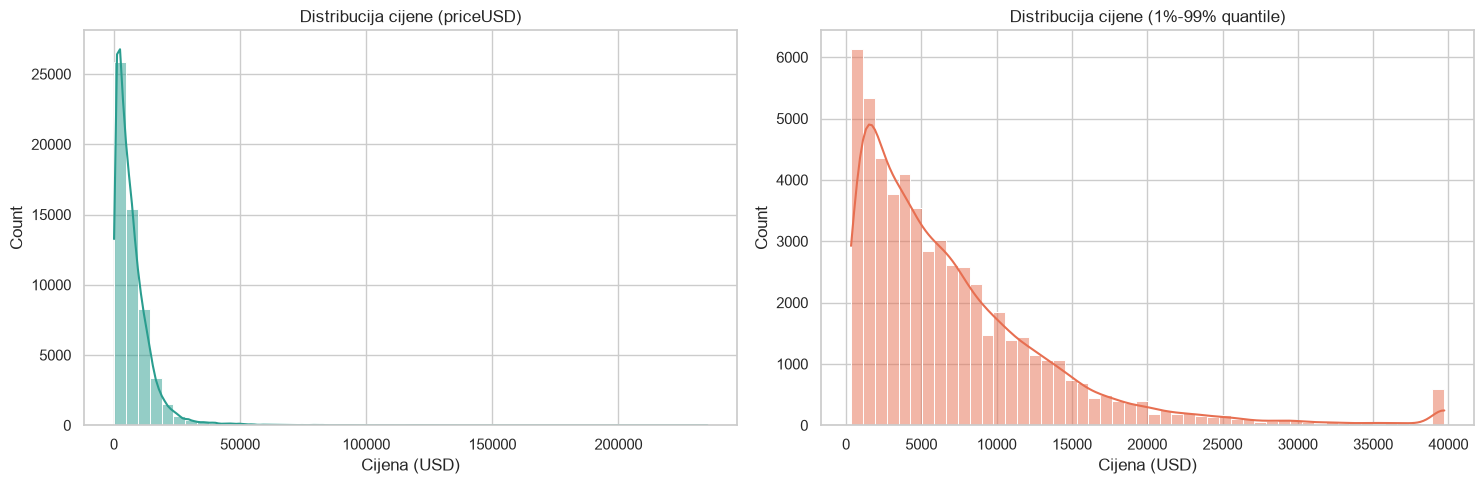

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=df_raw, x='priceUSD', bins=50, kde=True, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Distribucija cijene (priceUSD)')
axes[0].set_xlabel('Cijena (USD)')

price_clip = df_raw['priceUSD'].clip(
    lower=df_raw['priceUSD'].quantile(0.01),
    upper=df_raw['priceUSD'].quantile(0.99),
)
price_clip_df = price_clip.to_frame(name='priceUSD')
sns.histplot(data=price_clip_df, x='priceUSD', bins=50, kde=True, ax=axes[1], color='#e76f51')
axes[1].set_title('Distribucija cijene (1%-99% quantile)')
axes[1].set_xlabel('Cijena (USD)')

plt.tight_layout()

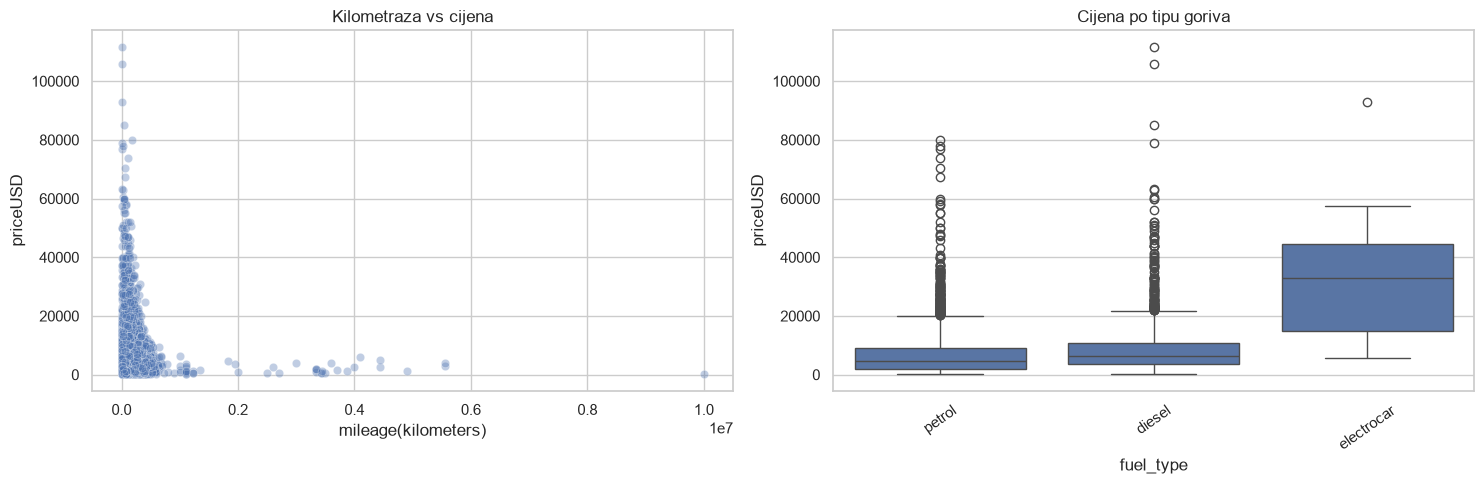

In [7]:
sample_df = df_raw.sample(min(6000, len(df_raw)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=sample_df, x='mileage(kilometers)', y='priceUSD', alpha=0.35, ax=axes[0])
axes[0].set_title('Kilometraza vs cijena')

sns.boxplot(data=sample_df, x='fuel_type', y='priceUSD', ax=axes[1])
axes[1].set_title('Cijena po tipu goriva')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()

In [8]:
cat_cols = ['make', 'model', 'condition', 'fuel_type', 'transmission', 'drive_unit', 'segment']
for col in cat_cols:
    print(f'\nTop vrijednosti - {col}:')
    print(df_raw[col].value_counts(dropna=False).head(10))


Top vrijednosti - make:
make
volkswagen       6861
audi             4030
bmw              4013
opel             3779
renault          3713
mercedes-benz    3541
ford             3078
peugeot          2876
nissan           2233
toyota           2177
Name: count, dtype: int64

Top vrijednosti - model:
model
passat      2086
5-seriya    1476
a6          1276
golf        1070
astra       1013
e-klass      988
3-seriya     823
vectra       815
laguna       768
mondeo       731
Name: count, dtype: int64

Top vrijednosti - condition:
condition
with mileage    55278
with damage       512
for parts         454
Name: count, dtype: int64

Top vrijednosti - fuel_type:
fuel_type
petrol        36405
diesel        19792
electrocar       47
Name: count, dtype: int64

Top vrijednosti - transmission:
transmission
mechanics    36056
auto         20188
Name: count, dtype: int64

Top vrijednosti - drive_unit:
drive_unit
front-wheel drive             38016
rear drive                     6836
all-wheel driv

## 3. Data Cleaning

The cleaning step prepares the raw dataset for modeling.

Main cleaning decisions:

- rename problematic column names such as `mileage(kilometers)` and `volume(cm3)`
- normalize categorical text values
- convert price, year, mileage and engine volume to numeric values
- remove duplicate rows
- remove invalid rows, such as non-positive prices or negative mileage
- filter extreme outliers in price and mileage using quantiles
- handle missing values in selected columns

This step is important because bad input data can lead to misleading model results.

## 4. Feature Engineering

Feature engineering creates additional columns that may help the model understand the car better.

Created features:

- `car_age`: older cars usually have lower prices
- `mileage_per_year`: shows how intensively the car was used
- `engine_volume_liters`: easier interpretation of engine size
- `is_newer_car`: marks newer vehicles
- `is_high_mileage`: marks cars with very high mileage
- `brand_model`: combines make and model because some models strongly affect price

These features are useful because car price is not determined only by one column. It depends on a combination of age, mileage, brand, model, engine and condition.

In [9]:
df_clean = clean_cars_data(df_raw)
df_feat = engineer_features(df_clean)

print(f'Clean shape: {df_clean.shape}')
print(f'Featured shape: {df_feat.shape}')
df_feat.head()

Clean shape: (53685, 12)
Featured shape: (53685, 18)


,make,model,priceUSD,year,condition,mileage_km,fuel_type,engine_volume_cm3,color,transmission,drive_unit,segment,car_age,mileage_per_year,engine_volume_liters,is_newer_car,is_high_mileage,brand_model
0,mazda,2,5500,2008,with mileage,162000.0,petrol,1500.0,burgundy,mechanics,front-wheel drive,b,18,9000.000000,1.5,0,0,mazda_2
1,mazda,2,5350,2009,with mileage,120000.0,petrol,1300.0,black,mechanics,front-wheel drive,b,17,7058.823529,1.3,0,0,mazda_2
2,mazda,2,7000,2009,with mileage,61000.0,petrol,1500.0,silver,auto,front-wheel drive,b,17,3588.235294,1.5,0,0,mazda_2
3,mazda,2,3300,2003,with mileage,265000.0,diesel,1400.0,white,mechanics,front-wheel drive,b,23,11521.739130,1.4,0,1,mazda_2
4,mazda,2,5200,2008,with mileage,97183.0,diesel,1400.0,gray,mechanics,front-wheel drive,b,18,5399.055556,1.4,0,0,mazda_2


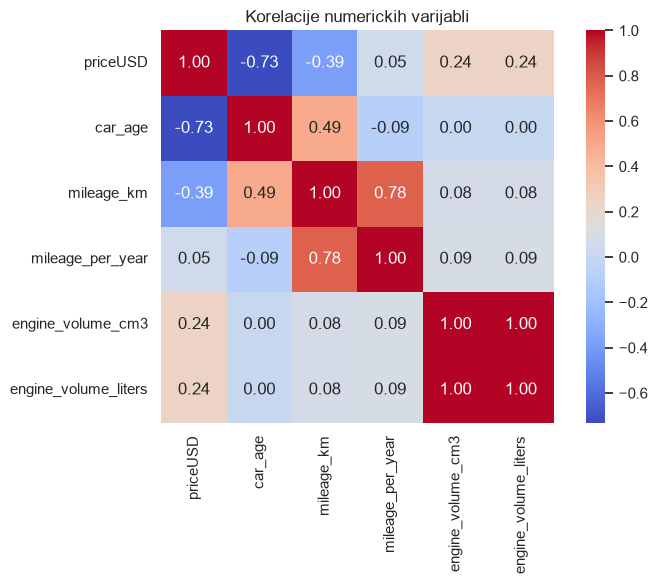

In [10]:
engineered_num_cols = [
    'priceUSD',
    'car_age',
    'mileage_km',
    'mileage_per_year',
    'engine_volume_cm3',
    'engine_volume_liters',
]

corr = df_feat[engineered_num_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Korelacije numerickih varijabli')
plt.tight_layout()

## 5. Preprocessing

The dataset contains both numerical and categorical columns.

Numerical columns are processed with:

- `SimpleImputer` using median values
- `StandardScaler`

Categorical columns are processed with:

- `SimpleImputer` using the most frequent value
- `OneHotEncoder` with `handle_unknown="ignore"`

This is necessary because machine learning models cannot directly use raw text categories such as make, fuel type or transmission.

In [13]:
from src.data_preprocessing import TARGET_COLUMN, build_preprocessing_artifacts

artifacts = build_preprocessing_artifacts(df_feat, target_column=TARGET_COLUMN)
print(f'Number of numeric columns: {len(artifacts.numeric_columns)}')
print(f'Number of categorical columns: {len(artifacts.categorical_columns)}')
print('Numeric columns sample:', artifacts.numeric_columns[:6])
print('Categorical columns sample:', artifacts.categorical_columns[:6])

Number of numeric columns: 8
Number of categorical columns: 9
Numeric columns sample: ['year', 'mileage_km', 'engine_volume_cm3', 'car_age', 'mileage_per_year', 'engine_volume_liters']
Categorical columns sample: ['make', 'model', 'condition', 'fuel_type', 'color', 'transmission']


## 6. Model Comparison

I tested several regression algorithms on the same train/test split:

- Linear Regression
- Ridge Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor

Using the same split makes the comparison fair.

The main evaluation metrics are:

- MAE
- MSE
- RMSE
- R2

For this task, MAE is especially important because it is easy to interpret. For example, if MAE is 1000, the model is wrong by about 1000 USD on average.

In [14]:
comparison_path = project_root / 'reports' / 'model_comparison.csv'
comparison_df = pd.read_csv(comparison_path)
comparison_df

,model,mae,mse,rmse,r2
0,random_forest,958.567478,2.790036e+06,1670.339988,0.921747
1,decision_tree,1145.904439,3.936493e+06,1984.059837,0.889591
2,gradient_boosting,1314.285625,4.168239e+06,2041.626469,0.883092
3,linear_regression,1623.317891,6.099088e+06,2469.633199,0.828936
4,ridge,1625.207100,6.116159e+06,2473.086876,0.828457


## 7. Model Selection

The best performing model is Random Forest Regressor.

It achieved the best overall result:

- MAE: 958.57 USD
- RMSE: 1670.34 USD
- R2: 0.9217

This means that the model explains a large part of the variation in used car prices and makes an average error of about 959 USD.

Random Forest performs better than linear models because car prices usually depend on nonlinear relationships. For example, the effect of mileage is not always the same for every brand, model or production year.

## 8. Prediction Examples

Besides metrics, it is useful to inspect actual predictions.

The table below compares:

- actual price
- predicted price
- prediction error

This helps explain model performance in a practical way. For a business user, seeing real examples is often easier to understand than only looking at MAE, RMSE or R2.

In [12]:
predictions_path = project_root / 'reports' / 'sample_predictions.csv'
predictions_df = pd.read_csv(predictions_path)
predictions_df.head(20)

,actual_price,predicted_price,error
0,13250,12635.751921,-614.248079
1,5500,5618.619926,118.619926
2,10300,10799.069365,499.069365
3,3000,3042.865460,42.865460
4,1600,820.018796,-779.981204
5,5200,5251.263429,51.263429
6,28521,23349.929095,-5171.070905
7,18000,19186.883000,1186.883000
8,9300,10078.850534,778.850534
9,6900,7587.503825,687.503825


## 9. Final Conclusion

This project solves a used car price prediction problem using a complete regression workflow.

The final selected model is Random Forest Regressor because it achieved the lowest MAE and RMSE and the highest R2 score among the tested models.

The most important metric for this project is MAE because it directly shows the average prediction error in USD. The final MAE is about 958.57 USD, which means that the model is wrong by about 959 USD on average.

This result is useful for a prototype system that estimates realistic used car prices. The model should not be treated as a perfect price calculator, but it can help sellers and platform teams understand whether a listed price is realistic.

Possible future improvements:

- tune Random Forest hyperparameters
- test Gradient Boosting or XGBoost
- add more detailed brand/model statistics
- handle rare car models more carefully
- add prediction intervals instead of only one price
- build a simple interactive prediction script or web interface